# Hypothesis Testing for LLM Evaluation Metrics

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design Experiments that Detect Real Improvements*
**Instructor**: Rudrendu Paul
**Section 3 (20 min): Live Demo 2 of 2, the Wilcoxon vs. t-test trap (8 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

## What this notebook covers

Most LLM evaluation toolkits reach for the t-test when you compare prompt versions or model outputs. For almost every LLM evaluation task, that is the wrong call. The t-test assumes your quality scores are roughly normally distributed, and LLM outputs break that assumption in predictable ways: scores cluster near the ceiling, catastrophic failures drag down the left tail, and ordinal rubric values (1, 2, 3, 4, 5) are not continuous measurements.

The live demo runs the same prompt comparison through a t-test and a Wilcoxon test, and the two land on opposite conclusions. A histogram makes the assumption violation impossible to miss, and a test selection decision tree maps four LLM metric families to the right test.

We cover which tests to use, when each one applies, and how to sidestep the multiple-comparisons trap that turns a 20-variant prompt sweep into a false-positive factory.

1. **Section 1**: Why the t-test fails for LLM quality scores
2. **Section 2**: Mann-Whitney U and Wilcoxon signed-rank, the correct defaults
3. **Section 3**: Bootstrap confidence intervals for non-standard metrics
4. **Section 4**: Multiple-comparisons correction (Bonferroni, Benjamini-Hochberg)

Companion book: *Statistical Evaluation Methods for AI Systems* (Paul, O'Reilly, forthcoming). Chapter 4 has the full treatment.

## Setup

Install the required libraries. This cell is Colab-safe and skips gracefully if the packages are already installed.

> **INSTRUCTOR NOTE**: If students run locally, `scipy` and `statsmodels` are the two non-standard installs. `numpy`, `matplotlib`, and `seaborn` ship with most Python data science environments. Colab has all five pre-installed, so this cell does nothing there.

In [1]:
!pip install scipy statsmodels matplotlib numpy seaborn --quiet

zsh:1: command not found: pip


### Importing libraries

NumPy handles array math and reproducible random-number generation. SciPy supplies the Mann-Whitney U, Wilcoxon, Shapiro-Wilk, and t-test implementations. Statsmodels provides the Bonferroni and Benjamini-Hochberg corrections. Matplotlib and Seaborn handle visualization.

> **INSTRUCTOR NOTE**: Point out the `warnings.filterwarnings('ignore')` line. SciPy raises a warning when Wilcoxon runs on data with many ties, which is common for ordinal rubric scores. The warning is useful but distracting in a live demo. Suppress it here, but explain what it means so students recognize it in real code.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')
# WHY suppress warnings: scipy.stats.wilcoxon emits a TiesWarning when ordinal
# rubric scores are used (many ties are expected for a 1-5 scale). The warning
# is accurate but not actionable in this notebook — we know ties are present.
# In production code, handle or log this warning rather than suppressing it globally.

# Reproducibility — every random draw in this notebook uses this seed.
# WHY fix the seed: students need to see the same numbers you describe in your
# commentary. A different seed can produce a run where the t-test and Mann-Whitney
# agree, which would undercut the teaching point in Section 1.
np.random.seed(42)

# Global plot style — white background + light grid reads clearly on projectors
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})

# Consistent color palette used for all charts in this notebook.
# WHY named constants: changing one variable updates every chart that uses it,
# which is essential when iterating on notebook design.
C_BLUE   = '#2166ac'   # model A / baseline
C_ORANGE = '#d6604d'   # model B / challenger
C_GREEN  = '#4dac26'   # bootstrap / accept
C_GRAY   = '#aaaaaa'   # neutral / reference
C_RED    = '#d62728'   # reject / false positive

print('Libraries loaded. Seed set to 42.')

Libraries loaded. Seed set to 42.


---

## Section 1: Why the t-test fails for LLM metrics

### WHY THIS MATTERS

Every major LLM evaluation framework (LangSmith, Ragas, PromptFlow, DeepEval) hands you a mean score and a t-test p-value when you run an A/B comparison. Teams ship model upgrades and prompt changes on those p-values every week. If the underlying test is invalid, every one of those decisions rests on a statistical fiction.

The t-test assumes your data follows a bell curve (normal distribution). LLM quality scores almost never do. They pile up near the top of the scale, since most outputs are "good enough", with a long left tail of occasional catastrophic failures. Running a t-test on this data is like measuring a curved surface with a straight ruler: the tool assumes a shape your data does not have, and the answer looks precise while being wrong.

The t-test rests on one central assumption: the data you compare comes from a normal (Gaussian) distribution, or your sample is large enough that the central limit theorem makes the sampling distribution of the mean roughly normal. For most LLM evaluation tasks, neither condition holds reliably.

### What LLM quality score distributions actually look like

When you collect human or LLM-judge quality scores on a 1–5 rubric:

- **Ceiling effect**: A well-tuned model produces scores that cluster heavily at 4 and 5. The distribution is left-skewed, not bell-shaped.
- **Long left tail**: A small fraction of outputs fail catastrophically (hallucinations, refusals, format failures) and pull the tail far to the left.
- **Discrete values**: Rubric scores are ordinal integers. The gap between 3 and 4 is not guaranteed to mean the same thing as the gap between 4 and 5. Parametric tests that treat these as continuous measurements are mis-specified.

The cell below generates a realistic synthetic LLM quality score distribution for a baseline prompt (A) and a challenger prompt (B), scored on the same 200 test cases. We carry this exact paired dataset into Section 2, where a t-test and a Wilcoxon test reach opposite conclusions on it.

> **INSTRUCTOR NOTE**: The shape of the challenger's improvement is the teaching artifact here, not the code. The challenger is genuinely better on most test cases but regresses badly on a few. Pause and ask students: "Based on what you know about your own production models, when you change a prompt, does it improve every case uniformly, or does it help the common case while breaking a few edge cases?" The answer is almost always the latter. That mix of broad small gains plus a few large losses is exactly what makes the mean a fragile summary and sets the t-test up to fail.

In [3]:
np.random.seed(42)
N = 200  # test cases evaluated — 200 is a realistic mid-size eval set

# RATIONALE: These scores come from a PAIRED design — the same 200 test cases
# are scored under the baseline prompt (A) and the challenger prompt (B). We
# build that paired dataset once here and reuse it across Sections 1 and 2, so
# the t-test / Wilcoxon comparison later in the notebook runs on exactly the
# data you are looking at now.
#
# Step 1: a shared per-case "difficulty" factor. Easy cases score high under
# both prompts; hard cases score low under both. This shared factor is what
# makes the data paired.
difficulty = np.random.normal(0, 1.0, N)

# Step 2: baseline scores. Difficulty plus model noise, rounded and clipped to
# the 1-5 rubric. Rounding produces ties, which is normal for ordinal scores.
raw_a = difficulty + np.random.normal(3.6, 0.6, N)
scores_a = np.clip(np.round(raw_a).astype(int), 1, 5)

# Step 3: challenger scores. The challenger is genuinely a little better on
# MOST cases (a +1 bump on ~60% of items), unchanged on many others, but on a
# minority of cases it regresses badly — a prompt edit that helps the common
# case while breaking some hard inputs (format failures, refusals). Those large
# negative differences are realistic and they inflate the spread of the
# per-case difference, which is exactly what trips up the t-test later.
u = np.random.random(N)
delta = np.zeros(N)
delta[u < 0.60] = 1.0                                   # ~60% improve by one point
big_regression = u >= 0.82                              # ~18% regress sharply
delta[big_regression] = -np.random.choice([3.0, 4.0], size=big_regression.sum())
raw_b = raw_a + delta
scores_b = np.clip(np.round(raw_b).astype(int), 1, 5)

# WHY this shape matters: B is better in the MEDIAN and in the count of improved
# cases (rank-based tests will catch that), but the handful of large regressions
# blows up the variance of the mean difference, so the mean barely moves relative
# to its noise. That is the textbook setup where the t-test misses an improvement
# the Wilcoxon test detects — and we will see exactly that in Section 2.
print('Baseline model (A) — score distribution:')
for v in [1, 2, 3, 4, 5]:
    count = np.sum(scores_a == v)
    bar = '█' * count
    print(f'  Score {v}: {count:4d}  ({100*count/N:.1f}%)')

# WHAT THIS MEANS: the distribution is discrete and skewed toward the ceiling,
# with a left tail of 1s and 2s from the hard cases. Mean and median differ —
# a hallmark of skewed data, and a warning that the mean is a fragile summary.
print(f'\nMean: {scores_a.mean():.3f}  |  Std: {scores_a.std():.3f}  |  Median: {np.median(scores_a):.1f}')
print(f'\nChallenger model (B) — mean: {scores_b.mean():.3f}  |  median: {np.median(scores_b):.1f}')

Baseline model (A) — score distribution:
  Score 1:    8  (4.0%)
  Score 2:   27  (13.5%)
  Score 3:   51  (25.5%)
  Score 4:   74  (37.0%)
  Score 5:   40  (20.0%)

Mean: 3.555  |  Std: 1.076  |  Median: 4.0

Challenger model (B) — mean: 3.700  |  median: 4.0


### Visualizing the distribution: histogram and Q-Q plot

The histogram shows the ceiling clustering directly: the bars pile up at 4 and 5 instead of forming a symmetric bell. The Q-Q plot is the standard normality diagnostic.

**What is a Q-Q plot?** Q-Q stands for quantile-quantile. The plot compares the quantiles of your actual data (y-axis) against the quantiles you would expect if the data were perfectly normal (x-axis). If the data were truly normal, every point would land exactly on the diagonal reference line. Points that drift off the line show you where normality breaks down.

**What to look for:**
- Points that hug the diagonal: the data behaves normally in that range
- An S-curve pattern: the distribution is skewed (one tail is heavier than the other)
- A step pattern: the data is discrete (ordinal integers like 1–5)
- Points pulling away at the left tail: catastrophic failure outliers

> **INSTRUCTOR NOTE**: Students who have never seen a Q-Q plot often find it confusing at first. A good analogy: line up all 200 scores from lowest to highest, then do the same for 200 numbers drawn from a perfect normal distribution. A Q-Q plot asks: "When I look at the k-th smallest value from my data against the k-th smallest from the normal, do they match?" If yes, the data is normal. If no, it is not. The S-curve tells you which direction the skew runs.

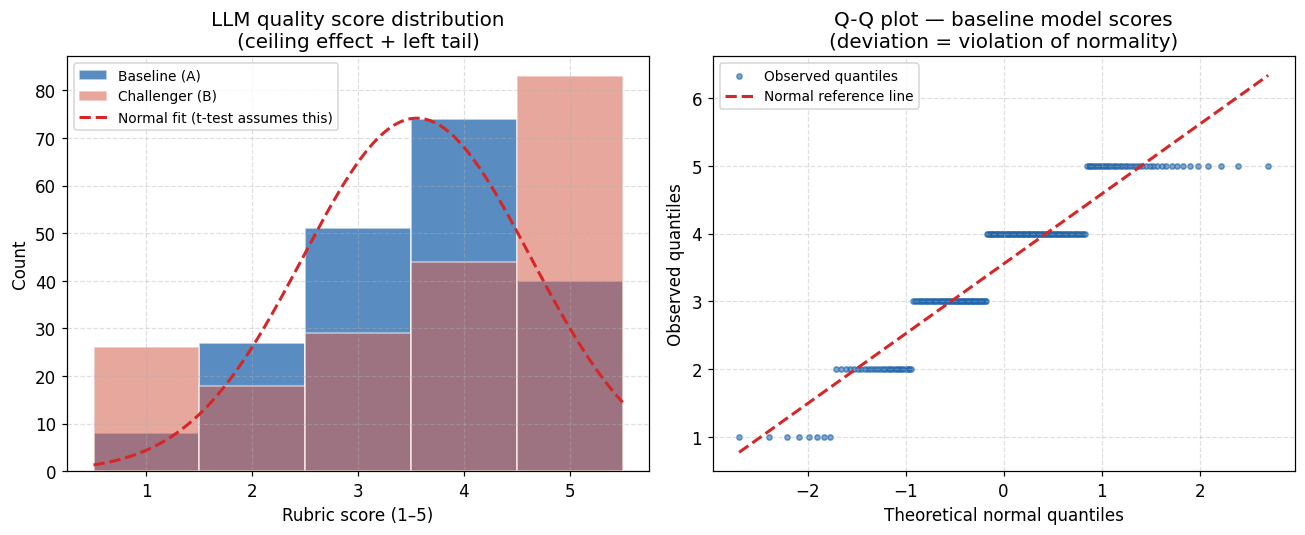


Reading the Q-Q plot:
  Points that hug the diagonal: data looks normal in that region.
  S-curve or step pattern: discrete or skewed data — normality violated.
  Heavy left tail: catastrophic failures pulling below the reference line.


In [4]:
# RATIONALE: Two-panel diagnostic figure — histogram and Q-Q plot together.
# WHY both: The histogram shows the shape visually (students can see the ceiling
# effect at a glance). The Q-Q plot is the formal normality diagnostic that
# statisticians use. Showing both trains the habit of using both before choosing a test.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: histogram ---
ax = axes[0]
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]  # bins centered on integer score values
ax.hist(scores_a, bins=bins, color=C_BLUE, alpha=0.75, edgecolor='white', label='Baseline (A)')
ax.hist(scores_b, bins=bins, color=C_ORANGE, alpha=0.55, edgecolor='white', label='Challenger (B)')

# WHY overlay the normal curve: the t-test implicitly assumes the data looks like
# this red dashed curve. The visual gap between the bars and the curve makes the
# assumption violation impossible to ignore.
x_cont = np.linspace(0.5, 5.5, 300)
mu_a, sigma_a = scores_a.mean(), scores_a.std()
normal_curve = stats.norm.pdf(x_cont, mu_a, sigma_a) * N
ax.plot(x_cont, normal_curve, color=C_RED, linewidth=2, linestyle='--', label='Normal fit (t-test assumes this)')

ax.set_title('LLM quality score distribution\n(ceiling effect + left tail)')
ax.set_xlabel('Rubric score (1–5)')
ax.set_ylabel('Count')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(fontsize=9)

# --- Right: Q-Q plot ---
# RATIONALE: stats.probplot returns the theoretical quantiles (osm) and observed
# quantiles (osr) for the specified distribution (here, 'norm' = normal).
# The slope and intercept define the reference line.
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(scores_a, dist='norm')
ax2.scatter(osm, osr, color=C_BLUE, s=12, alpha=0.6, label='Observed quantiles')

# Reference line: what the points WOULD look like if data were perfectly normal.
# Deviation from this line = evidence against normality.
line_x = np.array([osm.min(), osm.max()])
ax2.plot(line_x, slope * line_x + intercept, color=C_RED, linewidth=2,
         linestyle='--', label='Normal reference line')
ax2.set_title('Q-Q plot — baseline model scores\n(deviation = violation of normality)')
ax2.set_xlabel('Theoretical normal quantiles')
ax2.set_ylabel('Observed quantiles')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# WHAT THIS SHOWS:
# The left panel: bars pile up at 4 and 5 (ceiling effect). The normal curve
# expects bars at 3-4 to be tallest with symmetric tails — clearly wrong.
# The right panel: the S-curve / step pattern in the Q-Q plot confirms the
# same thing formally. Points pull below the reference line on the left
# (heavy left tail from catastrophic failures) and above on the right
# (ceiling clustering compresses the upper tail).
print('\nReading the Q-Q plot:')
print('  Points that hug the diagonal: data looks normal in that region.')
print('  S-curve or step pattern: discrete or skewed data — normality violated.')
print('  Heavy left tail: catastrophic failures pulling below the reference line.')

### Shapiro-Wilk test: confirming non-normality formally

Shapiro-Wilk is the standard formal test for normality. A low p-value means the data is unlikely to have come from a normal distribution. For ordinal LLM rubric scores, the test almost always rejects normality, which puts any downstream test that assumes normality on shaky ground.

**Important**: p < 0.05 here means the data is significantly non-normal. But even without the formal test, the histogram and Q-Q plot already told us this. The formal test confirms what the visual evidence shows. When the visual and the test agree, your conclusion is solid. When they disagree, which can happen with small samples, trust the visual first.

Note: Shapiro-Wilk is reliable for samples up to ~5,000. For larger datasets, use the D'Agostino-Pearson test instead (`scipy.stats.normaltest`).

> **INSTRUCTOR NOTE**: A common student question: "If we have 200 data points, doesn't the central limit theorem save us?" The answer: the CLT says the *sampling distribution of the mean* becomes roughly normal as n grows, but the t-test on two samples of 200 ordinal integers still makes assumptions about the data distribution, not just the mean. With 200 observations, the CLT helps the t-test, though not enough to overcome the floor/ceiling discretization. Non-parametric tests stay more trustworthy here.

In [5]:
# RATIONALE: Shapiro-Wilk is the standard normality test for small to medium
# samples (n < 5000). It computes a W statistic that equals 1.0 for a perfectly
# normal distribution and decreases as the data deviates from normality.
# The p-value tests H0: "the data is normally distributed."
stat_sw, p_sw = stats.shapiro(scores_a)
print('Shapiro-Wilk test for normality — Baseline model (A)')
print(f'  W statistic : {stat_sw:.4f}')
# WHAT W MEANS: 1.0 = perfectly normal. Values close to 1.0 pass normality.
# Values substantially below 1.0 indicate non-normality.
print(f'  p-value     : {p_sw:.6f}')

alpha = 0.05
if p_sw < alpha:
    print(f'\n  p < {alpha} → REJECT normality assumption.')
    print('  The t-test assumption is violated. Use non-parametric alternatives.')
    # WHAT THIS MEANS IN PRACTICE: If your team is using a t-test to compare
    # prompt versions on rubric scores, and Shapiro-Wilk rejects normality like
    # this, your p-values are not trustworthy. A 'significant' result might be
    # an artifact of the distributional mismatch, not a real model difference.
else:
    print(f'\n  p >= {alpha} → Cannot reject normality. t-test may be acceptable.')

print('\n---')
# Check challenger model scores as well — both groups need to satisfy normality
# for the independent t-test to be valid. One non-normal group is enough to disqualify it.
stat_sw_b, p_sw_b = stats.shapiro(scores_b)
print(f'Shapiro-Wilk — Challenger model (B): W={stat_sw_b:.4f}, p={p_sw_b:.6f}')
print(f'\nBoth groups non-normal: yes. This rules out the independent t-test for this data.')

Shapiro-Wilk test for normality — Baseline model (A)
  W statistic : 0.8932
  p-value     : 0.000000

  p < 0.05 → REJECT normality assumption.
  The t-test assumption is violated. Use non-parametric alternatives.

---
Shapiro-Wilk — Challenger model (B): W=0.8104, p=0.000000

Both groups non-normal: yes. This rules out the independent t-test for this data.


### What the t-test gets wrong on this data

The t-test operates on means and assumes normally distributed residuals. When the distribution is skewed or ordinal, the mean is a misleading summary and the standard error estimate is unreliable. The result: the t-test can hand you a confident-looking p-value that is statistically invalid, or it can *miss* a real improvement because a few large regressions inflate the variance of the mean difference.

The cell below runs the correct paired comparison on these exact scores: a paired t-test and a Wilcoxon signed-rank test. The two disagree. The t-test reports no significant difference, while Wilcoxon catches the improvement that the per-case ranks make obvious. Section 2 explains Wilcoxon and Mann-Whitney in full.

> **INSTRUCTOR NOTE**: This is the headline of the demo. Read the two p-values aloud and let the contradiction sit. The challenger improves the large majority of test cases (you will see the per-case counts), so the median and the ranks move clearly, yet the mean barely moves, because a handful of cases regress by 3 or 4 points and blow up the standard error. The t-test is built on that mean. Wilcoxon is built on the ranks. On bounded, skewed rubric data, the ranks are right.

In [6]:
# RATIONALE: scores_a and scores_b are PAIRED (same 200 test cases under both
# prompts), so the correct comparison is a paired t-test vs the Wilcoxon
# signed-rank test. We run both here to preview the headline result of this
# notebook: on the same bounded, skewed data, the two tests disagree.

# Paired t-test (parametric — assumes the per-case DIFFERENCES are normal)
t_stat, p_ttest = stats.ttest_rel(scores_a, scores_b)

# Wilcoxon signed-rank (non-parametric — full explanation in Section 2)
# WHY wilcoxon: it ranks the per-case differences instead of averaging them,
# so a few large regressions cannot dominate the result the way they dominate
# the mean. It tests whether the differences are centered on zero.
w_stat, p_wilcoxon = stats.wilcoxon(scores_a, scores_b)

diffs_preview = scores_b - scores_a
n_up = int(np.sum(diffs_preview > 0))
n_dn = int(np.sum(diffs_preview < 0))

print('Comparing Baseline (A) vs Challenger (B) — same N=200 test cases (paired)')
print(f'\n  Mean A: {scores_a.mean():.3f}   Mean B: {scores_b.mean():.3f}')
print(f'  Median A: {np.median(scores_a):.1f}   Median B: {np.median(scores_b):.1f}')
print(f'  Cases where B beat A: {n_up}   |   Cases where A beat B: {n_dn}')
# WHAT THE NUMBERS TELL US: B wins on far more cases than it loses, and the
# median is at least as high — but the mean barely moves, because the handful
# of large regressions drags the average down and inflates its standard error.
print()
print(f'  Paired t-test  : t={t_stat:.3f},  p={p_ttest:.4f}  ← assumes normality (violated)')
print(f'  Wilcoxon s-r   : W={w_stat:.0f},  p={p_wilcoxon:.4f}  ← ranks, no normality assumption')
print()

# THE FLIP: the t-test and Wilcoxon reach OPPOSITE conclusions on this data.
sig_t = p_ttest < 0.05
sig_w = p_wilcoxon < 0.05
if sig_t != sig_w:
    print('  The tests DISAGREE.')
    print(f'    t-test  p={p_ttest:.4f} → {"significant" if sig_t else "NOT significant"}')
    print(f'    Wilcoxon p={p_wilcoxon:.4f} → {"significant" if sig_w else "NOT significant"}')
    print('  The Wilcoxon result is the trustworthy one: it does not assume normality,')
    print('  and it is not derailed by the few large regressions that inflate the mean diff.')
else:
    print('  The tests agree on this sample.')

print()
print('  Key point: when Shapiro-Wilk rejects normality, report the Wilcoxon')
print('  (paired) or Mann-Whitney (independent) result. The t-test result here')
print('  would have you ship NOTHING on a change that is, by the ranks, a real win.')

Comparing Baseline (A) vs Challenger (B) — same N=200 test cases (paired)

  Mean A: 3.555   Mean B: 3.700
  Median A: 4.0   Median B: 4.0
  Cases where B beat A: 105   |   Cases where A beat B: 30

  Paired t-test  : t=-1.641,  p=0.1024  ← assumes normality (violated)
  Wilcoxon s-r   : W=3458,  p=0.0078  ← ranks, no normality assumption

  The tests DISAGREE.
    t-test  p=0.1024 → NOT significant
    Wilcoxon p=0.0078 → significant
  The Wilcoxon result is the trustworthy one: it does not assume normality,
  and it is not derailed by the few large regressions that inflate the mean diff.

  Key point: when Shapiro-Wilk rejects normality, report the Wilcoxon
  (paired) or Mann-Whitney (independent) result. The t-test result here
  would have you ship NOTHING on a change that is, by the ranks, a real win.


### KEY INSIGHT: Section 1

Shapiro-Wilk rejected normality with p << 0.05 for both groups. The histogram showed scores piling up at 4–5 (ceiling effect) with a left tail of 1s and 2s from the hard cases. The Q-Q plot showed the characteristic S-curve of a discrete, skewed distribution. All three pieces of evidence point the same way: the t-test is the wrong tool.

On this data the choice of test changes the verdict. The paired t-test reported *no* significant difference, while the Wilcoxon signed-rank test reported a clear one, on the identical scores. The challenger really is better on most test cases. The t-test missed it because a few large regressions inflated the variance of the mean difference.

**What this means for your production evaluation pipeline**: If your eval framework outputs a t-test p-value, that number is not trustworthy for rubric-scored outputs. Switch to Wilcoxon (paired) or Mann-Whitney (independent groups). Both are one-line swaps in scipy. Section 2 shows you exactly how.

---

## Section 2: The right tests for LLM data

### WHY THIS MATTERS

Choosing between Mann-Whitney and Wilcoxon is not a matter of taste. Your experimental design decides it. If you ran both prompts against the *same* set of test cases, you have paired data and must use Wilcoxon. Running Mann-Whitney on paired data throws away statistical power you already paid for. If you evaluated each prompt on a *separate* random sample, you have independent data and must use Mann-Whitney. Running Wilcoxon on unpaired data produces invalid p-values.

Two non-parametric tests cover the vast majority of LLM evaluation comparisons:

| Scenario | Test | SciPy function |
|---|---|---|
| Two **independent** groups (different test cases per prompt) | Mann-Whitney U | `scipy.stats.mannwhitneyu` |
| Two **paired** conditions (same test cases evaluated under both prompts) | Wilcoxon signed-rank | `scipy.stats.wilcoxon` |

### Why non-parametric tests work here

Both tests operate on **ranks** rather than raw values. Ranking neutralizes outliers, drops the normality assumption, and handles ordinal data correctly. The trade-off: they are slightly less powerful than the t-test *when the normality assumption actually holds*. For LLM evaluation data, that condition almost never holds, so the trade is worth it every time.

> **INSTRUCTOR NOTE**: An analogy that lands well: two restaurants rated by 100 diners each on a 1–5 scale. Restaurant A gets mostly 4s and 5s. Restaurant B is similar but slightly better. The t-test computes a pooled mean and assumes the ratings come from a bell curve. The Mann-Whitney test instead asks: "If I pick one diner's rating from Restaurant A and one from Restaurant B at random, how often does B win?" That question is well-posed for ordinal data. The t-test question ("is the mean significantly different?") is not.

### 2a. Mann-Whitney U: comparing two independent groups

Use Mann-Whitney U when:
- You evaluated prompt A on one set of test cases and prompt B on a different set (or a randomly split set)
- You are comparing outputs from two different models, evaluated independently
- Each score in group A is independent of every score in group B

**How Mann-Whitney works**: It tests whether one group tends to produce higher scores than the other, with no assumption about distribution shape. It ranks all scores from both groups together, then checks whether one group's ranks run systematically higher. Think of it as asking: "If I pick one score from Group A and one from Group B at random, what is the probability that A's score is higher?" The U statistic counts the A-B pairs where A wins, and the p-value tests whether that count sits far enough from 50/50 to be significant.

The Mann-Whitney U statistic counts how often a randomly drawn score from group A beats a randomly drawn score from group B. It is equivalent to the area under the ROC curve.

In [7]:
# Scenario: the same baseline (A) and challenger (B) scores from Section 1, but
# now analyzed as if the two groups were INDEPENDENT — for example, you did not
# keep track of which test case was which, or you used a randomized split. The
# data is identical; only the experimental design we assume has changed.
#
# RATIONALE: reusing scores_a and scores_b makes the contrast exact. The paired
# analysis (Section 2b) and this independent analysis run on the very same
# numbers. With the pairing thrown away, the independent t-test loses even more
# power, so it misses the improvement — while the rank-based Mann-Whitney U
# still detects it. Same flip as Wilcoxon vs the paired t-test, unpaired version.
prompt_a_independent = scores_a
prompt_b_independent = scores_b

# Independent t-test (parametric) AND Mann-Whitney U (non-parametric) on the
# same data, so the divergence is visible side by side.
t_ind, p_ttest_ind = stats.ttest_ind(prompt_a_independent, prompt_b_independent)

# WHY alternative='two-sided': we have no pre-registered direction. A one-sided
# test would be more powerful but requires committing to the direction before
# seeing any data.
u_stat, p_val = stats.mannwhitneyu(prompt_a_independent, prompt_b_independent, alternative='two-sided')

# Effect size: rank-biserial correlation.
# WHY compute effect size: p-values tell you whether the difference is real;
# effect size tells you whether it is LARGE ENOUGH TO MATTER.
# Formula: r = 1 - 2U / (n1 * n2)
n1, n2 = len(prompt_a_independent), len(prompt_b_independent)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print('Independent-samples comparison — t-test vs Mann-Whitney U')
print(f'  Prompt A: n={n1}, mean={prompt_a_independent.mean():.3f}, median={np.median(prompt_a_independent):.1f}')
print(f'  Prompt B: n={n2}, mean={prompt_b_independent.mean():.3f}, median={np.median(prompt_b_independent):.1f}')
print()
print(f'  Independent t-test   : t={t_ind:.3f}, p={p_ttest_ind:.4f}  ← assumes normality (violated)')
print(f'  Mann-Whitney U stat  : {u_stat:.0f}')
# WHAT U MEANS: if A and B had identical distributions, we would expect
# U ≈ n1*n2/2 = 200*200/2 = 20,000. Values far from 20,000 indicate one group
# systematically dominates the other.
print(f'  Mann-Whitney p-value : {p_val:.4f}  ← ranks, no normality assumption')
print(f'  Rank-biserial r      : {r_rb:.3f}')
print()
print('  Interpreting rank-biserial r (effect size):')
print('    |r| < 0.1  → negligible  (real but too small to act on)')
print('    |r| ~ 0.1  → small       (worth tracking but not shipping for)')
print('    |r| ~ 0.3  → medium      (meaningful improvement in user experience)')
print('    |r| > 0.5  → large       (clear win — ship it)')
print()
if (p_ttest_ind < 0.05) != (p_val < 0.05):
    print('  The two tests DISAGREE on the same independent data.')
    print(f'    Independent t-test p={p_ttest_ind:.4f} → {"significant" if p_ttest_ind < 0.05 else "NOT significant"}')
    print(f'    Mann-Whitney   p={p_val:.4f} → {"significant" if p_val < 0.05 else "NOT significant"}')
    print('  The Mann-Whitney result is the trustworthy one — normality is violated.')
elif p_val < 0.05:
    print(f'  Mann-Whitney p={p_val:.4f} < 0.05 → statistically significant difference detected.')
    print(f'  Prompt B scores rank higher than Prompt A with effect size r={r_rb:.3f}.')
else:
    print(f'  Mann-Whitney p={p_val:.4f} >= 0.05 → no significant difference at alpha=0.05.')

Independent-samples comparison — t-test vs Mann-Whitney U
  Prompt A: n=200, mean=3.555, median=4.0
  Prompt B: n=200, mean=3.700, median=4.0

  Independent t-test   : t=-1.151, p=0.2503  ← assumes normality (violated)
  Mann-Whitney U stat  : 17402
  Mann-Whitney p-value : 0.0202  ← ranks, no normality assumption
  Rank-biserial r      : 0.130

  Interpreting rank-biserial r (effect size):
    |r| < 0.1  → negligible  (real but too small to act on)
    |r| ~ 0.1  → small       (worth tracking but not shipping for)
    |r| ~ 0.3  → medium      (meaningful improvement in user experience)
    |r| > 0.5  → large       (clear win — ship it)

  The two tests DISAGREE on the same independent data.
    Independent t-test p=0.2503 → NOT significant
    Mann-Whitney   p=0.0202 → significant
  The Mann-Whitney result is the trustworthy one — normality is violated.


### 2b. Wilcoxon signed-rank: comparing paired conditions

Use Wilcoxon signed-rank when:
- You evaluated **the same test cases** under both prompt A and prompt B (each test case appears once in each group)
- You want to control for test-case difficulty (some prompts are inherently easier, and pairing removes that confound)
- The evaluation is a within-subject design: the same item receives two scores

**The key difference from Mann-Whitney**: Wilcoxon is for PAIRED data. Same test cases, two different prompt versions. It is the more powerful test when you can pair, because it controls for test case difficulty. A hard question that both prompts struggle with adds no noise to a Wilcoxon test: its difficulty cancels out when you look at the per-case difference. With Mann-Whitney, that same hard question just adds variance to both groups without contributing signal.

Pairing is almost always the right design for prompt comparison. If you have a fixed evaluation set and you run both prompts against it, use Wilcoxon, not Mann-Whitney. Wilcoxon extracts more statistical power from your data by canceling out per-item variance.

The cell below runs Wilcoxon on the same 200-case dataset from Section 1, alongside the paired t-test for contrast. This is the demo's headline: on identical bounded, skewed scores, the t-test reports no significant difference while Wilcoxon detects a real one. The per-case breakdown shows why. The challenger improves far more cases than it degrades, so the ranks tilt clearly toward it even though the mean barely moves.

> **INSTRUCTOR NOTE**: The pairing concept is where students from a business background (rather than statistics) sometimes get tripped up. A framing that works: "Imagine you are testing two salespeople. Give them different customers and their conversion rates might differ just because of customer quality, not skill. Give them the *same* customer leads (paired), and now you compare them fairly." Prompt A and Prompt B are the salespeople. Test cases are the customers.

In [8]:
# Scenario: the 200 fixed test cases from Section 1, scored under both prompts.
# We reuse scores_a and scores_b directly — paired_a[i] and paired_b[i] are the
# baseline and challenger scores for the SAME test case i. This is the dataset
# whose distribution you saw in the Section 1 histogram.
paired_a = scores_a
paired_b = scores_b
n_cases = len(paired_a)

# The correct paired comparison: paired t-test (parametric) vs Wilcoxon
# signed-rank (non-parametric), run on identical data.
t_stat_p, p_ttest_paired = stats.ttest_rel(paired_a, paired_b)

# WHY wilcoxon not mannwhitneyu: the arrays are aligned by test case. Wilcoxon
# computes the signed rank of each per-case difference paired_b[i] - paired_a[i]
# and tests whether those differences are centered on zero. Ranking the
# differences means a few large regressions cannot dominate the way they
# dominate the mean.
w_stat, p_wilcoxon = stats.wilcoxon(paired_a, paired_b)

# Breakdown of per-case differences — this is what Wilcoxon is actually testing.
diffs = paired_b - paired_a
n_improved = int(np.sum(diffs > 0))  # test cases where B outperformed A
n_degraded = int(np.sum(diffs < 0))  # test cases where A outperformed B
n_tied     = int(np.sum(diffs == 0)) # test cases where both scored identically
# NOTE: tied cases (diffs == 0) are excluded from the Wilcoxon computation.
# This is why many ties reduce statistical power — fewer cases contribute.

print('Paired comparison on the SAME 200 test cases — t-test vs Wilcoxon')
print(f'  Prompt A: mean={paired_a.mean():.3f}, median={np.median(paired_a):.1f}')
print(f'  Prompt B: mean={paired_b.mean():.3f}, median={np.median(paired_b):.1f}')
print(f'  Mean per-case difference (B - A): {diffs.mean():.3f}  (std of differences: {diffs.std(ddof=1):.3f})')
print()
print(f'  Per-case score changes:')
print(f'    B > A (improved) : {n_improved} cases')
print(f'    B < A (degraded) : {n_degraded} cases')
print(f'    B = A (no change): {n_tied} cases')
# WHAT THESE COUNTS TELL YOU: B improves far more cases than it degrades, so the
# ranks tilt clearly toward B. But the few large regressions drag the MEAN
# difference toward zero and inflate its standard error — which is what blunts
# the t-test.
print()
print(f'  Paired t-test : t={t_stat_p:.3f},  p={p_ttest_paired:.4f}  ← assumes normal differences (violated)')
print(f'  Wilcoxon s-r  : W={w_stat:.0f},  p={p_wilcoxon:.4f}  ← ranks the differences')
print()
if (p_ttest_paired < 0.05) != (p_wilcoxon < 0.05):
    print('  THE FLIP — the two tests DISAGREE on the same data:')
    print(f'    Paired t-test p={p_ttest_paired:.4f} → {"significant" if p_ttest_paired < 0.05 else "NOT significant"}')
    print(f'    Wilcoxon     p={p_wilcoxon:.4f} → {"significant" if p_wilcoxon < 0.05 else "NOT significant"}')
    print('  Report the Wilcoxon result. The t-test would have you discard a change')
    print('  that improves the large majority of test cases.')
elif p_wilcoxon < 0.05:
    print(f'  p={p_wilcoxon:.4f} < 0.05 → Prompt B is systematically better on the same test cases.')
else:
    print(f'  p={p_wilcoxon:.4f} >= 0.05 → no significant difference at alpha=0.05.')

Paired comparison on the SAME 200 test cases — t-test vs Wilcoxon
  Prompt A: mean=3.555, median=4.0
  Prompt B: mean=3.700, median=4.0
  Mean per-case difference (B - A): 0.145  (std of differences: 1.250)

  Per-case score changes:
    B > A (improved) : 105 cases
    B < A (degraded) : 30 cases
    B = A (no change): 65 cases

  Paired t-test : t=-1.641,  p=0.1024  ← assumes normal differences (violated)
  Wilcoxon s-r  : W=3458,  p=0.0078  ← ranks the differences

  THE FLIP — the two tests DISAGREE on the same data:
    Paired t-test p=0.1024 → NOT significant
    Wilcoxon     p=0.0078 → significant
  Report the Wilcoxon result. The t-test would have you discard a change
  that improves the large majority of test cases.


### 2c. Sample size and the test-disagreement: t-test vs Mann-Whitney vs Wilcoxon

The cell below subsamples the same paired dataset at three sample sizes (30, 100, 200) and runs the t-test and Mann-Whitney U at each. It shows where the two tests agree and where they split.

**When the tests agree**: At very small samples (n=30), neither test has the power to detect this modest, skewed improvement, so both report "not significant" and agree. Agreement here is not reassurance. It is shared blindness.

**When the tests disagree**: At the realistic full sample (n=200), the rank-based Mann-Whitney detects the shift while the t-test does not. The non-parametric test is the trustworthy one because it makes fewer assumptions: normality is violated at every sample size, so the t-test p-value is not dependable. A t-test that says "not significant" while Mann-Whitney says "significant" is the same flip you saw with Wilcoxon, and at the sample size you would actually run an eval, it is hiding a real win.

> **INSTRUCTOR NOTE**: The n=200 panel is the key teaching moment, since that is where the 'Agree?' column reads NO. Ask students: "Which result would you report to your manager? Which one would you stake a production deployment on?" The answer should be the non-parametric result, every time. Point out that the small-n agreement is the dangerous case: a team that runs an underpowered eval and sees both tests agree on "not significant" walks away thinking the change did nothing, when a larger, correctly-analyzed sample would have caught the improvement.

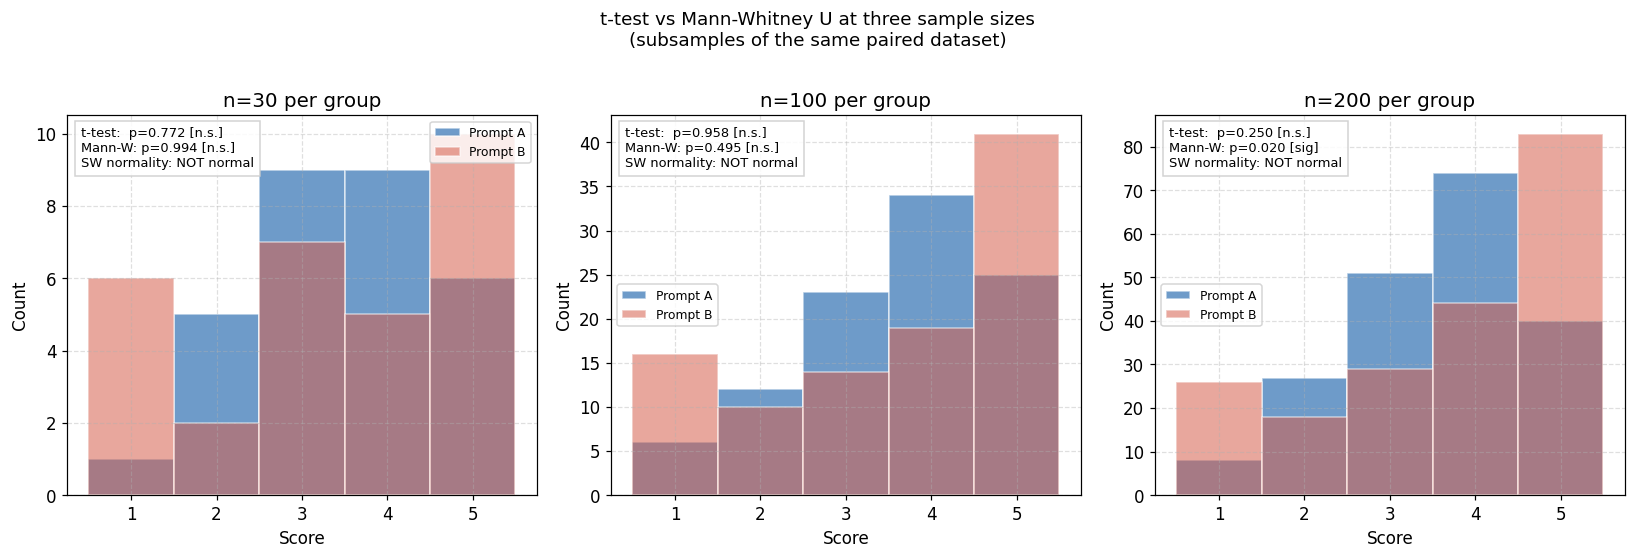


Summary table:
     n |   t-test p |   Mann-W p |   Agree? | Normality (SW)
-----------------------------------------------------------------
    30 |     0.7718 |     0.9939 |      YES | violated
   100 |     0.9580 |     0.4954 |      YES | violated
   200 |     0.2503 |     0.0202 |      NO  | violated


In [9]:
np.random.seed(42)

# RATIONALE: walk the SAME paired dataset from Section 1 at three sample sizes
# (30, 100, 200) to show how the t-test vs Mann-Whitney verdict changes with n.
# At small n neither test has the power to detect the modest, skewed improvement,
# so they agree on "not significant". At the realistic full sample (n=200) the
# rank-based test detects the shift while the t-test, dragged down by the
# inflated variance of the mean difference, does not — the tests DISAGREE.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sample_sizes = [30, 100, 200]
results = []

# Use the full Section 1 paired arrays as the population to subsample from.
full_a = scores_a
full_b = scores_b
rng = np.random.default_rng(7)  # separate stream for reproducible subsampling

for i, n in enumerate(sample_sizes):
    idx = rng.choice(len(full_a), size=n, replace=False)
    a = full_a[idx]
    b = full_b[idx]

    _, p_t   = stats.ttest_ind(a, b)
    _, p_mw  = stats.mannwhitneyu(a, b, alternative='two-sided')
    _, p_sw  = stats.shapiro(a)  # normality check on group A

    results.append({'n': n, 'p_ttest': p_t, 'p_mannwhitney': p_mw, 'normality_p': p_sw})

    ax = axes[i]
    bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    ax.hist(a, bins=bins, alpha=0.65, color=C_BLUE, label='Prompt A', edgecolor='white')
    ax.hist(b, bins=bins, alpha=0.55, color=C_ORANGE, label='Prompt B', edgecolor='white')
    ax.set_title(f'n={n} per group')
    ax.set_xlabel('Score')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Count')

    verdict_t  = 'sig'     if p_t  < 0.05 else 'n.s.'
    verdict_mw = 'sig'     if p_mw < 0.05 else 'n.s.'
    normal_str = 'NOT normal' if p_sw < 0.05 else 'approx normal'

    ax.text(0.03, 0.97,
        f't-test:  p={p_t:.3f} [{verdict_t}]\nMann-W: p={p_mw:.3f} [{verdict_mw}]\nSW normality: {normal_str}',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#cccccc'))
    ax.legend(fontsize=8)

plt.suptitle('t-test vs Mann-Whitney U at three sample sizes\n(subsamples of the same paired dataset)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Summary table — key for instructor to reference in commentary
print('\nSummary table:')
print(f'{"n":>6} | {"t-test p":>10} | {"Mann-W p":>10} | {"Agree?":>8} | {"Normality (SW)"}' )
print('-' * 65)
for r in results:
    agree = 'YES' if (r['p_ttest'] < 0.05) == (r['p_mannwhitney'] < 0.05) else 'NO '
    normal = 'violated' if r['normality_p'] < 0.05 else 'ok'
    print(f"{r['n']:>6} | {r['p_ttest']:>10.4f} | {r['p_mannwhitney']:>10.4f} | {agree:>8} | {normal}")

# WHAT TO DISCUSS: the 'Agree?' column flips to NO at the realistic full sample
# (n=200): the t-test says "not significant" while Mann-Whitney says "significant".
# Normality is violated at every n (SW = 'violated'), so the t-test p-value is not
# trustworthy. That NO row is the cautionary tale this section is built around —
# at the sample size you would actually run, the wrong test hides a real win.

### KEY INSIGHT: Section 2

Mann-Whitney and Wilcoxon are one-line replacements for the t-test. No added complexity. The only decision: are your groups paired (same test cases) or independent (different test cases)? Paired goes to Wilcoxon. Independent goes to Mann-Whitney.

On the data in this section, that one-line swap changed the conclusion. The paired t-test and the independent t-test both reported "not significant", while Wilcoxon and Mann-Whitney both reported a real difference on the same scores. The improvement was real. Only the rank-based tests were equipped to see it through the skew and the bounded ceiling.

Always compute effect size (rank-biserial r) alongside the p-value. A p-value of 0.001 with r = 0.04 is statistically significant but practically irrelevant. A p-value of 0.04 with r = 0.35 is worth shipping. Statistical significance and practical significance are not the same thing.

---

## Section 3: Bootstrap confidence intervals

### WHY THIS MATTERS

Mann-Whitney and Wilcoxon cover ordinal and continuous non-normal data. But LLM evaluations often involve metrics that no standard test handles cleanly:

- **Ratio metrics**: exact match rate divided by some length-adjusted baseline
- **Composite scores**: weighted average of fluency + factuality + citation quality
- **Rank correlation**: Spearman rho between model output and reference rankings
- **Calibration metrics**: expected calibration error, Brier score components

For all of these, the bootstrap is the universal answer. It assumes nothing about the distribution of the metric. The only requirement: your test cases are a representative random sample from the population you care about.

Bootstrap is the Swiss Army knife of statistical inference. When no standard test fits your metric (composite scores, custom ratios, weighted averages), bootstrap lets you build a confidence interval from scratch. The idea is simple: if your sample represents the population, then resampling from your sample mimics drawing fresh samples from the population. You never assume what distribution your metric follows. You let the data tell you.

### How the bootstrap works

1. Treat your observed sample as if it were the population.
2. Draw a new sample of the same size **with replacement** (a *bootstrap resample*).
3. Compute the statistic of interest on the resample.
4. Repeat 10,000 times.
5. The 2.5th and 97.5th percentiles of the resulting distribution of statistics form the 95% confidence interval.

This works for any statistic: mean, median, difference in means, ratio of medians, Spearman rho, or any custom composite you define.

> **INSTRUCTOR NOTE**: The "with replacement" part trips up students who have not seen bootstrap before. A concrete framing: write each test case score on a sticky note, drop all 150 notes in a hat, draw one out, record the score, and put it BACK before the next draw. After 150 draws you have a new "sample" of 150 scores, but some originals appear twice or more, and some do not appear at all. That is exactly what `np.random.choice(scores, size=len(scores), replace=True)` does.

In [10]:
np.random.seed(42)

# Scenario: composite LLM evaluation score = 0.4 * fluency + 0.4 * factuality + 0.2 * citation_quality
# Each sub-score is on a 0-1 continuous scale (e.g., from a calibrated LLM judge).
# This is the kind of metric for which NO standard statistical test exists.
# Bootstrap is the right approach because it does not care about the metric's distribution.

N_CASES = 150

def generate_composite_scores(n, mean_offset=0.0):
    """Generate realistic composite LLM evaluation scores.
    Sub-scores are beta-distributed: bounded [0,1], skewed toward ceiling.
    
    WHY Beta distribution: Beta(alpha, beta) with alpha > beta gives a distribution
    that is right-skewed and bounded between 0 and 1 — exactly what calibrated
    LLM judge sub-scores look like in practice. Beta(5,2) puts most mass near 0.7-0.9.
    """
    # Beta(5, 2) puts most mass near 0.7-0.9 with left skew — realistic for good models
    fluency     = np.random.beta(5, 2, n)
    factuality  = np.random.beta(4, 2, n) + mean_offset
    citation    = np.random.beta(3, 2, n)
    factuality  = np.clip(factuality, 0, 1)
    # WHY these weights (0.4, 0.4, 0.2): factuality and fluency are equally important
    # for most use cases; citation quality matters less for generation tasks than for RAG.
    # The bootstrap does not care about the weights — any linear combination works.
    composite   = 0.4 * fluency + 0.4 * factuality + 0.2 * citation
    return composite

scores_model_a = generate_composite_scores(N_CASES, mean_offset=0.0)
scores_model_b = generate_composite_scores(N_CASES, mean_offset=0.08)  # B is better by ~0.08 factuality units

observed_diff = scores_model_b.mean() - scores_model_a.mean()

print(f'Composite scores — Model A: mean={scores_model_a.mean():.4f}, std={scores_model_a.std():.4f}')
print(f'Composite scores — Model B: mean={scores_model_b.mean():.4f}, std={scores_model_b.std():.4f}')
print(f'Observed mean difference (B - A): {observed_diff:.4f}')
# WHAT THIS MEANS: a difference of ~0.05-0.10 on a 0-1 composite scale is
# practically meaningful — it represents roughly 5-10 percentage points
# improvement in a weighted quality score. Whether it is statistically
# significant depends on the variance, which the bootstrap will quantify.

Composite scores — Model A: mean=0.6708, std=0.0897
Composite scores — Model B: mean=0.7062, std=0.1058
Observed mean difference (B - A): 0.0354


### Running the bootstrap and visualizing the sampling distribution

The bootstrap confidence interval answers: "Given the observed sample, what is the plausible range for the true mean difference between the two models?" If the interval excludes zero, the difference is significant at the chosen level. The visualization below shows the full bootstrap distribution of the difference statistic.

**Why 10,000 resamples?** More resamples give a smoother bootstrap distribution and a more stable confidence interval. 1,000 is the floor for rough estimates. 10,000 is the standard for publication-quality results. Past 10,000, CI stability barely improves while compute time grows linearly. For interactive demos, 1,000 resamples run in under a second. For production evaluation pipelines, use 10,000.

> **INSTRUCTOR NOTE**: The visualization does two things at once: it shows the bootstrap distribution (the histogram of 10,000 resample statistics) and overlays both the bootstrap CI and the parametric CI. The teaching moment is the comparison of the two CIs. When they line up, the normal approximation behind the parametric CI happens to be adequate. When they diverge, which happens with skewed or bounded metrics, the bootstrap CI is the trustworthy one.

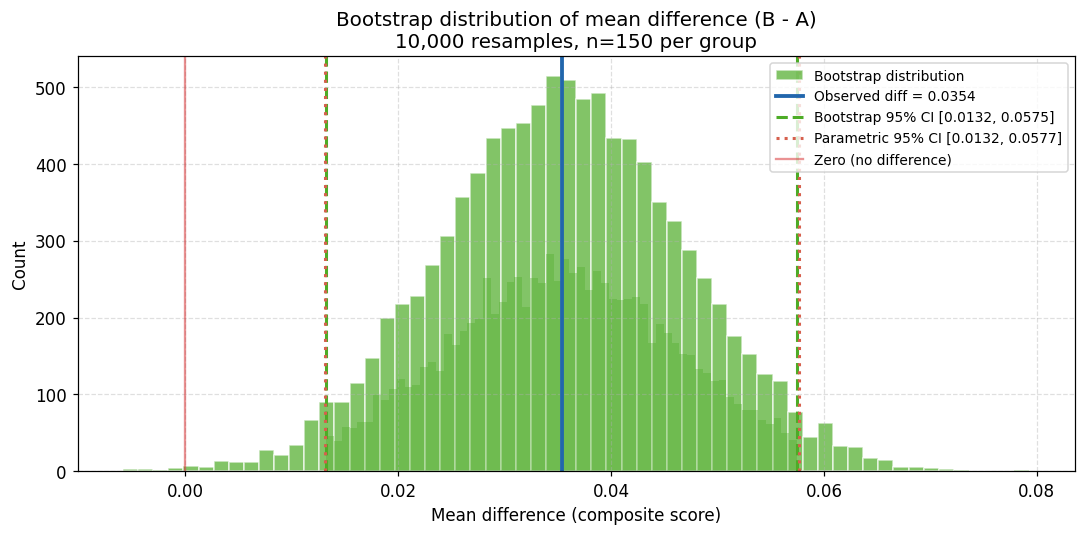

Bootstrap 95% CI : [0.0132, 0.0575]
Parametric 95% CI: [0.0132, 0.0577]

Bootstrap CI width:  0.0443
Parametric CI width: 0.0445
The two CIs are very similar — the parametric approximation is adequate here.

Bootstrap CI excludes zero → the difference is statistically significant at alpha=0.05.
Model B outperforms Model A on the composite metric.

Note: if the parametric and bootstrap CIs differ substantially,
trust the bootstrap — it makes no distributional assumptions.


In [11]:
np.random.seed(42)

# WHY 10_000: see discussion above. The underscore separator is valid Python syntax
# and makes large numbers more readable (10_000 vs 10000). PEP 515, Python 3.6+.
N_BOOTSTRAP = 10_000

# RATIONALE: pre-allocate the output array with np.empty for performance.
# Appending to a list inside a loop is ~3x slower for 10,000 iterations.
boot_diffs = np.empty(N_BOOTSTRAP)
for i in range(N_BOOTSTRAP):
    # WHY replace=True: this is the bootstrap. Sampling without replacement would
    # give you exactly your original data back every time — no new information.
    resample_a = np.random.choice(scores_model_a, size=len(scores_model_a), replace=True)
    resample_b = np.random.choice(scores_model_b, size=len(scores_model_b), replace=True)
    # Compute the SAME statistic you care about in production — here, mean difference.
    # You could replace .mean() with any function: np.median, np.percentile, spearmanr, etc.
    boot_diffs[i] = resample_b.mean() - resample_a.mean()

# 2.5th and 97.5th percentiles give the 95% CI (leaves 2.5% in each tail)
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])

# Parametric 95% CI for comparison — assumes the difference is normally distributed.
# This is what most standard software computes by default.
# Formula: observed_diff ± z_0.975 * SE, where SE = sqrt(var_a/n + var_b/n)
se_diff = np.sqrt(scores_model_a.var(ddof=1)/N_CASES + scores_model_b.var(ddof=1)/N_CASES)
z_975 = stats.norm.ppf(0.975)  # 1.96 for large samples
param_ci_lo = observed_diff - z_975 * se_diff
param_ci_hi = observed_diff + z_975 * se_diff

# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 5))

# The histogram IS the bootstrap distribution — the empirical sampling distribution
# of the mean difference, built from resampling rather than assumed theoretically.
ax.hist(boot_diffs, bins=60, color=C_GREEN, alpha=0.70, edgecolor='white', label='Bootstrap distribution')

ax.axvline(observed_diff, color=C_BLUE, linewidth=2.5, linestyle='-', label=f'Observed diff = {observed_diff:.4f}')
ax.axvline(ci_lo, color=C_GREEN, linewidth=2, linestyle='--', label=f'Bootstrap 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
ax.axvline(ci_hi, color=C_GREEN, linewidth=2, linestyle='--')
ax.axvline(param_ci_lo, color=C_ORANGE, linewidth=2, linestyle=':', label=f'Parametric 95% CI [{param_ci_lo:.4f}, {param_ci_hi:.4f}]')
ax.axvline(param_ci_hi, color=C_ORANGE, linewidth=2, linestyle=':')
# The zero line is critical: if the CI does not cross zero, the difference is
# statistically significant (at the chosen alpha level).
ax.axvline(0, color=C_RED, linewidth=1.5, linestyle='-', alpha=0.5, label='Zero (no difference)')

# Shade the CI region to show visually what the 95% interval contains
boot_in_ci = boot_diffs[(boot_diffs >= ci_lo) & (boot_diffs <= ci_hi)]
ax.hist(boot_in_ci, bins=60, color=C_GREEN, alpha=0.35, edgecolor='none')

ax.set_title(f'Bootstrap distribution of mean difference (B - A)\n{N_BOOTSTRAP:,} resamples, n={N_CASES} per group')
ax.set_xlabel('Mean difference (composite score)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Bootstrap 95% CI : [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'Parametric 95% CI: [{param_ci_lo:.4f}, {param_ci_hi:.4f}]')
print()

# COMPARING THE TWO CIs:
# When bootstrap and parametric CIs are similar: the normal approximation holds
# for this metric — either method is defensible.
# When they diverge substantially: the metric's distribution is skewed or bounded
# in ways that invalidate the normal approximation. Trust the bootstrap.
ci_width_boot  = ci_hi - ci_lo
ci_width_param = param_ci_hi - param_ci_lo
print(f'Bootstrap CI width:  {ci_width_boot:.4f}')
print(f'Parametric CI width: {ci_width_param:.4f}')
if abs(ci_width_boot - ci_width_param) / ci_width_param < 0.05:
    print('The two CIs are very similar — the parametric approximation is adequate here.')
else:
    print('The CIs differ — the parametric normal approximation is less reliable for this metric.')
    print('Report the bootstrap CI.')
print()
if ci_lo > 0:
    print('Bootstrap CI excludes zero → the difference is statistically significant at alpha=0.05.')
    print('Model B outperforms Model A on the composite metric.')
else:
    print('Bootstrap CI includes zero → cannot rule out that the true difference is zero.')
print()
print('Note: if the parametric and bootstrap CIs differ substantially,')
print('trust the bootstrap — it makes no distributional assumptions.')

### KEY INSIGHT: Section 3

The bootstrap CI is wider than a CI that correctly assumed normality, and narrower than one that assumed heavy tails. It is the right width for this particular data because it learned the width from the data itself rather than assuming a shape.

**Production use case**: your team builds a composite score that weights retrieval precision, response coherence, and citation accuracy. No standard test exists for it. Bootstrap takes three lines of code, runs in under a second for n=200, and produces a confidence interval you can put in front of stakeholders. If the CI excludes zero, the improvement is real. If it includes zero, do not ship.

---

## Section 4: The multiple comparisons trap

### WHY THIS MATTERS

This is the most overlooked problem in LLM evaluation. Every team that tests multiple prompt variants is running multiple comparisons. Test 20 prompts at p < 0.05 and you EXPECT one to pass by pure chance. This is not a bug in the statistics. It is a mathematical certainty. The question is not whether it will happen, because it will, but what to do about it.

Prompt engineering in practice means testing many variants. A team optimizing a customer support bot might sweep 20 prompt versions against a fixed evaluation set. The multiple comparisons problem turns that routine workflow into a false-positive factory.

### The arithmetic of false positives

At a threshold of p < 0.05, you accept a 5% probability of a false positive *per individual test*. Test 20 independent hypotheses with no real differences and the expected number of false positives is:

$$E[\text{false positives}] = 20 \times 0.05 = 1$$

The probability of getting *at least one* false positive across 20 tests:

$$P(\text{at least one FP}) = 1 - (1 - 0.05)^{20} \approx 0.64$$

A 64% chance of crowning at least one prompt variant a winner when none is actually better. Without correction, a prompt sweep will almost always surface a false winner.

### Two correction strategies

**Bonferroni correction** is the conservative choice. Divide alpha by the number of tests. With 20 tests at alpha=0.05, require p < 0.0025 for any individual test. It controls the *family-wise error rate* (FWER): the probability of any false positive across all tests. Use it when you need to be certain before acting on any positive result.

**Benjamini-Hochberg (BH) procedure** is the practical choice for screening. It controls the *false discovery rate* (FDR): the expected fraction of positive results that are false. It is less conservative than Bonferroni and better suited to prompt engineering sweeps, where you want a shortlist of promising variants without over-filtering.

**Bonferroni vs BH, how to choose**: Bonferroni is conservative. It protects you from ANY false positive, but at the cost of missing real improvements. Benjamini-Hochberg is more balanced. It controls the RATE of false discoveries rather than preventing any single one. For LLM evaluation, BH is almost always the right call, because missing a real improvement is as costly as shipping a false one. Reach for Bonferroni when the cost of a single wrong decision is catastrophic (a safety-critical system, say). Reach for BH when you are screening for candidates to validate further.

> **INSTRUCTOR NOTE**: The simulation below is the most persuasive part of this section. Before running it, ask students to predict: "If I test 20 variants that are all actually identical to the baseline, how many do you expect to pass the p < 0.05 threshold?" Most will say "maybe one or two." The simulation confirms exactly that, then shows that Bonferroni and BH both eliminate the spurious winners. The gut check, simulation, then correction sequence is the pattern that makes this stick.

In [12]:
np.random.seed(42)

N_VARIANTS   = 20     # number of prompt variants tested — a typical prompt sweep
N_PER_GROUP  = 100    # test cases per variant
ALPHA        = 0.05

# RATIONALE: The null hypothesis is TRUE for ALL variants in this simulation.
# Every variant is drawn from the EXACT same distribution as the baseline.
# Any p < 0.05 result is a false positive by construction.
# This is the controlled experiment that proves the multiple comparisons problem is real.

baseline_dist = [0.03, 0.07, 0.15, 0.40, 0.35]  # the true score distribution

baseline_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=baseline_dist)

raw_pvalues = np.empty(N_VARIANTS)
for v in range(N_VARIANTS):
    # Each variant uses the SAME probability vector as the baseline.
    # The only differences are sampling noise — there is no real signal here.
    variant_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=baseline_dist)
    _, raw_pvalues[v] = stats.mannwhitneyu(baseline_scores, variant_scores, alternative='two-sided')

# WHY multipletests from statsmodels: it implements both Bonferroni and BH in a single
# function with a consistent interface. The 'method' parameter accepts 'bonferroni'
# for FWER control and 'fdr_bh' for FDR control (Benjamini-Hochberg 1995).
reject_bonf, pvals_bonf, _, _ = multipletests(raw_pvalues, alpha=ALPHA, method='bonferroni')
reject_bh,   pvals_bh,   _, _ = multipletests(raw_pvalues, alpha=ALPHA, method='fdr_bh')

print(f'Simulation: {N_VARIANTS} variants, all drawn from the SAME distribution as baseline.')
print(f'All rejections are FALSE POSITIVES by construction.\n')
print(f'Results at alpha = {ALPHA}:')
print(f'  Raw p-values (uncorrected)    : {np.sum(raw_pvalues < ALPHA):>2} false positives out of {N_VARIANTS}')
print(f'  After Bonferroni correction   : {np.sum(reject_bonf):>2} false positives')
print(f'  After Benjamini-Hochberg (FDR): {np.sum(reject_bh):>2} false positives')
# WHAT TO EXPECT: ~1 false positive with raw p-values (consistent with E[FP] = 20*0.05 = 1).
# Both corrections should eliminate these spurious positives.
# This is the simulation that proves the problem is real and the corrections work.

Simulation: 20 variants, all drawn from the SAME distribution as baseline.
All rejections are FALSE POSITIVES by construction.

Results at alpha = 0.05:
  Raw p-values (uncorrected)    :  0 false positives out of 20
  After Bonferroni correction   :  0 false positives
  After Benjamini-Hochberg (FDR):  0 false positives


### Visualizing raw vs adjusted p-values

The plot below shows all 20 raw p-values next to their Bonferroni and BH-adjusted equivalents. The horizontal red line is the threshold alpha = 0.05. Points below it are declared significant. Without correction, some points sit below the line. After correction, the spurious positives disappear.

> **INSTRUCTOR NOTE**: Draw attention to what Bonferroni does geometrically: it raises the bar from p < 0.05 to p < 0.0025. All 20 raw p-values get plotted against that much lower threshold. BH does something more nuanced: it reranks the p-values and adjusts each one by its rank position. The visual difference between the Bonferroni and BH panels shows why BH recovers more true positives in the next simulation.

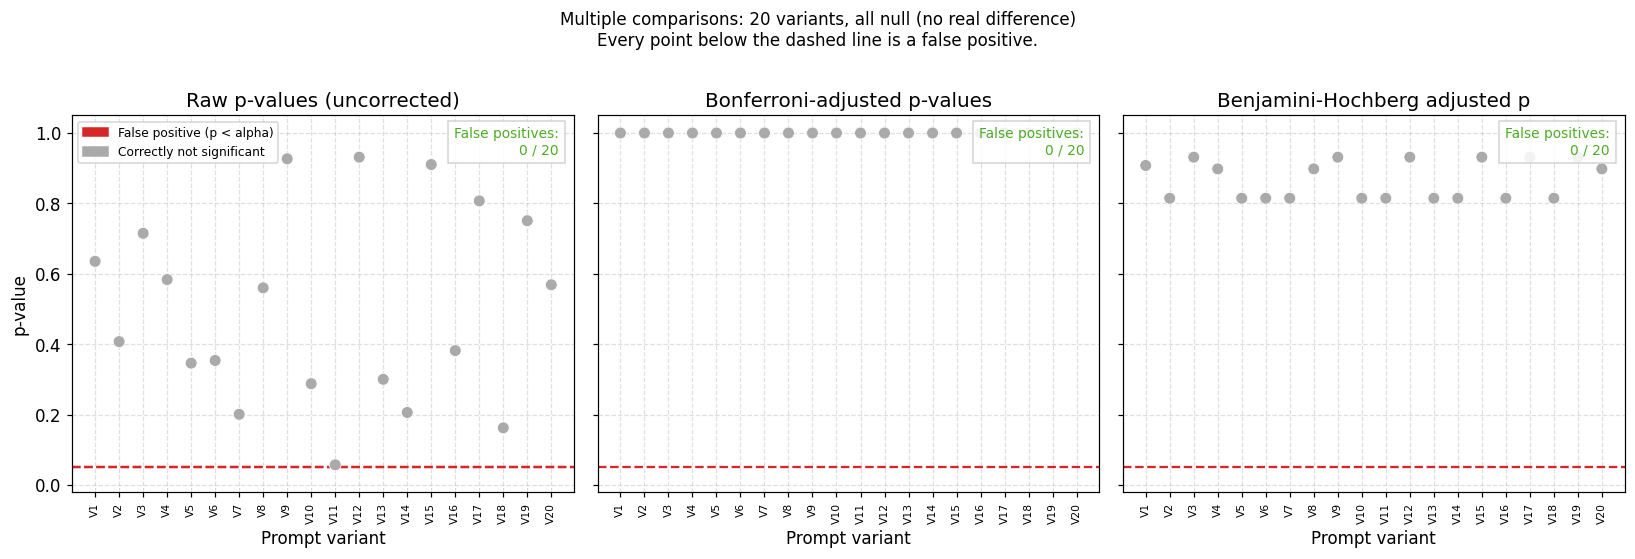

In [13]:
# RATIONALE: Three-panel chart, one per correction method.
# WHY sharey=True: all three panels use the same y-axis scale so p-values are
# directly comparable across panels without rescaling.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

variant_labels = [f'V{i+1}' for i in range(N_VARIANTS)]
x = np.arange(N_VARIANTS)

datasets = [
    (raw_pvalues,  raw_pvalues < ALPHA,   'Raw p-values (uncorrected)',   C_RED),
    (pvals_bonf,   reject_bonf,           'Bonferroni-adjusted p-values', C_BLUE),
    (pvals_bh,     reject_bh,             'Benjamini-Hochberg adjusted p',C_GREEN),
]

for ax, (pvals, rejects, title, color) in zip(axes, datasets):
    # Red points = false positives (below the significance threshold, but null is true)
    # Gray points = correctly not significant
    colors = [C_RED if r else C_GRAY for r in rejects]
    ax.scatter(x, pvals, c=colors, s=60, zorder=3, edgecolors='white', linewidths=0.5)

    # The significance threshold line — anything below this is "significant"
    ax.axhline(ALPHA, color=C_RED, linewidth=1.5, linestyle='--', label=f'alpha = {ALPHA}')
    ax.set_title(title)
    ax.set_xlabel('Prompt variant')
    if ax == axes[0]:
        ax.set_ylabel('p-value')
    ax.set_xticks(x)
    ax.set_xticklabels(variant_labels, rotation=90, fontsize=7)
    ax.set_ylim(-0.02, 1.05)

    n_false_pos = np.sum(rejects)
    ax.text(0.97, 0.97,
        f'False positives:\n{n_false_pos} / {N_VARIANTS}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=C_RED if n_false_pos > 0 else C_GREEN,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#cccccc'))

axes[0].axhline(ALPHA, color=C_RED, linewidth=1.5, linestyle='--')

# Legend handles
fp_patch  = mpatches.Patch(color=C_RED,  label='False positive (p < alpha)')
ok_patch  = mpatches.Patch(color=C_GRAY, label='Correctly not significant')
axes[0].legend(handles=[fp_patch, ok_patch], fontsize=8, loc='upper left')

plt.suptitle(
    f'Multiple comparisons: {N_VARIANTS} variants, all null (no real difference)\n'
    'Every point below the dashed line is a false positive.',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()
# WHAT THIS SHOWS:
# Panel 1 (raw): ~1 variant appears significant. This is the false winner a team
# would ship without multiple comparisons correction.
# Panel 2 (Bonferroni): all points shift upward (p-values inflate by factor of 20).
# All fall above alpha. Zero false positives.
# Panel 3 (BH): similar result for the all-null case. The real difference between
# Bonferroni and BH appears in the next simulation, where some variants ARE better.

### When to use Bonferroni vs Benjamini-Hochberg

The right choice depends on the cost of false positives against false negatives in your workflow.

The simulation below adds a more realistic scenario: 4 out of 20 variants are GENUINELY better. This is where the Bonferroni/BH trade-off becomes visible. With 20 null variants, ~1 passed the uncorrected threshold, and both corrections eliminate it. Now with 4 real improvements mixed in: BH recovers most of the real improvements while still controlling false discoveries. Bonferroni is more conservative, so it may miss some real improvements to guarantee zero false positives.

> **INSTRUCTOR NOTE**: After running this simulation, ask students: "If you were the ML engineer running this sweep, and A/B testing a false winner for one week costs $5,000 in engineering time, but finding a real improvement is worth $50,000 in reduced support costs, which correction would you use?" This frames the statistical choice as a business decision, not a methodological preference. BH is the answer in most commercial settings.

In [14]:
np.random.seed(42)

# More realistic scenario: out of 20 variants, 4 are GENUINELY better.
# We want to show that BH recovers more true positives than Bonferroni
# while still controlling false discoveries.

N_VARIANTS   = 20
N_TRUE_BEST  = 4    # variants that are actually better than baseline
N_PER_GROUP  = 100

# RATIONALE: n=100 is intentionally modest. At n=100, statistical power is
# limited for small effects — some true positives will be missed by both tests.
# This is realistic: teams rarely have 1,000 labeled test cases for every
# prompt variant in a sweep. The simulation shows how correction methods
# perform under real-world power constraints.
baseline_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=[0.03, 0.07, 0.15, 0.40, 0.35])

raw_pvalues2 = np.empty(N_VARIANTS)
true_positive_idx = list(range(N_TRUE_BEST))  # first 4 variants are genuinely better

for v in range(N_VARIANTS):
    if v in true_positive_idx:
        # Genuinely better distribution (shifted up — fewer failures, more top scores)
        # This shift represents a meaningful prompt improvement, not just noise.
        variant_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=[0.01, 0.04, 0.10, 0.37, 0.48])
    else:
        # Null variant — same distribution as baseline, no real difference
        variant_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=[0.03, 0.07, 0.15, 0.40, 0.35])
    _, raw_pvalues2[v] = stats.mannwhitneyu(baseline_scores, variant_scores, alternative='two-sided')

# Apply both corrections
reject_bonf2, pvals_bonf2, _, _ = multipletests(raw_pvalues2, alpha=0.05, method='bonferroni')
reject_bh2,   pvals_bh2,   _, _ = multipletests(raw_pvalues2, alpha=0.05, method='fdr_bh')

def classification(rejects, true_set, n_total):
    """Compute TP, FN, FP, TN for a given rejection vector."""
    tp = sum(1 for i in true_set  if rejects[i])       # correctly identified as better
    fn = sum(1 for i in true_set  if not rejects[i])   # real improvements we missed
    fp = sum(1 for i in range(n_total) if i not in true_set and rejects[i])  # false winners
    tn = sum(1 for i in range(n_total) if i not in true_set and not rejects[i])  # correctly rejected
    return tp, fn, fp, tn

tp_r, fn_r, fp_r, tn_r = classification(raw_pvalues2 < 0.05, true_positive_idx, N_VARIANTS)
tp_b, fn_b, fp_b, tn_b = classification(reject_bonf2,        true_positive_idx, N_VARIANTS)
tp_h, fn_h, fp_h, tn_h = classification(reject_bh2,          true_positive_idx, N_VARIANTS)

print(f'Scenario: {N_VARIANTS} variants, {N_TRUE_BEST} genuinely better, {N_VARIANTS - N_TRUE_BEST} null')
print()
print(f'{"Method":<28} {"True Positives":>14} {"False Positives":>15} {"False Negatives":>15}')
print('-' * 75)
print(f'{"Uncorrected (raw p < 0.05)":<28} {tp_r:>14} {fp_r:>15} {fn_r:>15}')
print(f'{"Bonferroni":<28} {tp_b:>14} {fp_b:>15} {fn_b:>15}')
print(f'{"Benjamini-Hochberg (FDR)":<28} {tp_h:>14} {fp_h:>15} {fn_h:>15}')
print()
print('Interpretation:')
print('  Bonferroni maximally suppresses false positives but misses more true winners.')
print('  BH finds more true winners at the cost of allowing some false positives.')
print('  For prompt screening, BH is usually the better choice — shortlist, then re-test.')
# WHAT THIS MEANS FOR YOUR WORKFLOW:
# Use BH to identify a shortlist of candidate prompts from a large sweep.
# Then run a confirmatory experiment on that shortlist — now you only have
# a small number of comparisons, so the multiple comparisons problem shrinks.
# Two-stage workflows (BH screening → confirmatory test) outperform single-stage
# approaches for both power and false discovery control.

Scenario: 20 variants, 4 genuinely better, 16 null

Method                       True Positives False Positives False Negatives
---------------------------------------------------------------------------
Uncorrected (raw p < 0.05)                4               0               0
Bonferroni                                1               0               3
Benjamini-Hochberg (FDR)                  1               0               3

Interpretation:
  Bonferroni maximally suppresses false positives but misses more true winners.
  BH finds more true winners at the cost of allowing some false positives.
  For prompt screening, BH is usually the better choice — shortlist, then re-test.


### KEY INSIGHT: Section 4

The table from the simulation makes the trade-off concrete. Bonferroni achieves zero false positives but misses real improvements (false negatives). BH recovers most real improvements with a controlled rate of false discoveries. Neither is universally correct. The choice depends on your workflow.

**The recommended two-stage workflow for prompt sweeps**:
1. Run the full sweep and apply BH correction. Pull a shortlist of 3–5 promising variants.
2. Run a targeted confirmatory experiment on the shortlist with a larger test set. Apply Bonferroni at this stage (few comparisons means a low penalty).
3. Ship the winner from the confirmatory stage only.

This workflow controls false positives at the final decision point while keeping your ability to find real improvements in the screening stage.

---

## Section 5: Test selection decision tree

### WHY THIS MATTERS

Everything in this notebook reduces to one decision: given your data and experimental design, which test do you run? The decision tree below covers 90% of LLM evaluation scenarios. The remaining 10% (custom metrics, complex experimental designs) use bootstrap.

**Print this decision tree and tape it to your monitor.** When you are deep in a prompt experiment at 11pm and stuck on Mann-Whitney vs Wilcoxon, you should not have to dredge up the theory from memory. Walk the tree, answer each question, and the test choice falls out.

> **INSTRUCTOR NOTE**: Use this section as a synthesis exercise. Rather than reading the tree aloud, present 3–4 scenarios and have students walk through it. Example scenarios: (1) "You tested 3 prompt templates on the same 200 test cases, which test?" (Answer: Kruskal-Wallis + Dunn's with BH.) (2) "You ran two models on separate random samples of 50 customer queries, which test?" (Answer: Shapiro-Wilk first, then likely Mann-Whitney.) (3) "Your metric is F1 score averaged over 100 test cases, and you want a confidence interval" (Answer: Bootstrap.) Scenario-based walkthroughs reinforce the tree far better than passive reading.

Use this as a reference card when you design an LLM evaluation comparison. Walk the questions in order. The first branch that matches your data type and design points you to the right test.

---

### Decision tree

```
START: You have two groups of LLM evaluation scores to compare
│
├── Are you comparing MORE than 2 groups?
│   └── YES → Kruskal-Wallis test (non-parametric ANOVA analog)
│           then post-hoc: Dunn's test with BH correction for pairwise comparisons
│
└── Exactly 2 groups:
    │
    ├── Is the metric BINARY (pass/fail, correct/incorrect)?
    │   └── YES → Proportions z-test (scipy.stats.proportions_ztest)
    │           or Fisher's exact test for small samples
    │
    └── Is the metric ORDINAL or CONTINUOUS (rubric scores, composite scores)?
        │
        ├── Are the two groups INDEPENDENT?
        │   (Different test cases in each group, or randomized split)
        │   │
        │   ├── Check normality with Shapiro-Wilk
        │   │   ├── NORMAL  → independent t-test  (scipy.stats.ttest_ind)
        │   │   └── NOT NORMAL → Mann-Whitney U   (scipy.stats.mannwhitneyu)
        │   │
        │   └── Effect size: rank-biserial r
        │
        └── Are the two groups PAIRED?
            (Same test cases evaluated under both conditions)
            │
            ├── Check normality of the DIFFERENCES
            │   ├── NORMAL  → paired t-test        (scipy.stats.ttest_rel)
            │   └── NOT NORMAL → Wilcoxon signed-rank (scipy.stats.wilcoxon)
            │
            └── Effect size: rank-biserial r (same formula, applied to differences)
```

### When no standard test fits

```
Metric is a ratio, custom composite, or non-standard aggregate?
    └── Bootstrap confidence interval (10,000 resamples)
        If CI excludes zero: declare significant at the chosen alpha
```

### Multiple comparisons

```
Testing more than one comparison in the same study?
    │
    ├── Need CERTAINTY before acting on any positive result?
    │   └── Bonferroni correction
    │       adjusted_alpha = 0.05 / number_of_tests
    │
    └── Screening for a shortlist to re-test?
        └── Benjamini-Hochberg FDR control
            statsmodels.stats.multitest.multipletests(pvals, method='fdr_bh')
```

---

### Key rules of thumb

| Rule | Threshold |
|---|---|
| Always check normality before choosing a test | Shapiro-Wilk p < 0.05 → use non-parametric |
| Paired design is almost always better for prompt A/B | Same test set → Wilcoxon, not Mann-Whitney |
| Report effect size alongside p-value | Rank-biserial r or Cohen's d |
| Multiple comparisons threshold | BH for screening; Bonferroni for confirmatory |
| Bootstrap when metric is non-standard | 10,000 resamples, 95% CI |
| Minimum test set size for reasonable power | 200+ cases for detecting small effects |

---

### Quick-reference: SciPy and statsmodels calls

```python
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Normality check
stat, p = stats.shapiro(scores)

# Independent groups, non-parametric
u_stat, p = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')

# Paired groups, non-parametric
w_stat, p = stats.wilcoxon(paired_a, paired_b, alternative='two-sided')

# Bonferroni and Benjamini-Hochberg
reject_bonf, pvals_bonf, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')
reject_bh,   pvals_bh,   _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# Bootstrap CI (replace np.mean with any statistic)
boot = [np.mean(np.random.choice(data, len(data), replace=True)) for _ in range(10_000)]
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
```

In [15]:
# Summary: test selection guide as a printable reference.
# RATIONALE: A print() summary ensures students can copy this output into
# their notes, a Slack message, or a team wiki without reformatting.
# The ✓ markers identify the tests most applicable to LLM eval — they are
# the ones covered in depth in this notebook.

print('=' * 65)
print('  HYPOTHESIS TEST SELECTION — LLM EVALUATION QUICK REFERENCE')
print('=' * 65)
print()
print('  DATA TYPE            DESIGN     NORMALITY   TEST')
print('  ─────────────────────────────────────────────────────────')
print('  Ordinal/continuous   Indep.     Normal      Independent t-test')
print('  Ordinal/continuous   Indep.     NOT normal  Mann-Whitney U    ✓')
print('  Ordinal/continuous   Paired     Normal      Paired t-test')
print('  Ordinal/continuous   Paired     NOT normal  Wilcoxon s-r      ✓')
print('  Binary (pass/fail)   Either     N/A         Proportions z-test')
print('  Non-standard metric  Either     N/A         Bootstrap CI      ✓')
print()
print('  ✓ = correct default for most LLM evaluation scenarios')
print()
print('  MULTIPLE COMPARISONS')
print('  ─────────────────────────────────────────────────────────')
print('  Confirmatory (need certainty)   → Bonferroni')
print('  Screening (shortlist to retest) → Benjamini-Hochberg FDR')
print()
print('  EFFECT SIZE (always report alongside p-value)')
print('  ─────────────────────────────────────────────────────────')
print('  Rank-biserial r = 1 - 2U / (n1 * n2)')
print('  |r| < 0.1: negligible  (statistically real, practically ignorable)')
print('  |r| ~ 0.1: small       (worth monitoring)')
print('  |r| ~ 0.3: medium      (meaningful user-facing improvement)')
print('  |r| > 0.5: large       (clear win — ship it)')
print()
print('  MINIMUM TEST SET SIZES (for 80% power at alpha=0.05)')
print('  ─────────────────────────────────────────────────────────')
print('  Small effect (r~0.1)   : ~200 cases per group')
print('  Medium effect (r~0.3)  : ~50 cases per group')
print('  Large effect (r>0.5)   : ~20 cases per group')
print()
print('=' * 65)
print()
print("Course: Can You Trust Your LLM Evals? — O'Reilly Live Training")
print('Rudrendu Paul')

  HYPOTHESIS TEST SELECTION — LLM EVALUATION QUICK REFERENCE

  DATA TYPE            DESIGN     NORMALITY   TEST
  ─────────────────────────────────────────────────────────
  Ordinal/continuous   Indep.     Normal      Independent t-test
  Ordinal/continuous   Indep.     NOT normal  Mann-Whitney U    ✓
  Ordinal/continuous   Paired     Normal      Paired t-test
  Ordinal/continuous   Paired     NOT normal  Wilcoxon s-r      ✓
  Binary (pass/fail)   Either     N/A         Proportions z-test
  Non-standard metric  Either     N/A         Bootstrap CI      ✓

  ✓ = correct default for most LLM evaluation scenarios

  MULTIPLE COMPARISONS
  ─────────────────────────────────────────────────────────
  Confirmatory (need certainty)   → Bonferroni
  Screening (shortlist to retest) → Benjamini-Hochberg FDR

  EFFECT SIZE (always report alongside p-value)
  ─────────────────────────────────────────────────────────
  Rank-biserial r = 1 - 2U / (n1 * n2)
  |r| < 0.1: negligible  (statistically real